In [2]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
# sys.path = original_sys_path

In [3]:
max_ql = 25
max_ol = 50
system = fluxonium_oscillator_system(
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 6.81289062,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '0,1',
    )



In [4]:
t_stop = 463
tot_time =500
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    intial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(3)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.004,
    t_stop = t_stop
)

 Total run time: 6282.94s] Elapsed 6282.94s / Remaining 00:00:00:00
 Total run time: 6687.03s] Elapsed 6687.03s / Remaining 00:00:00:00
 Total run time: 6723.68s] Elapsed 6723.68s / Remaining 00:00:00:00


In [5]:

# import pickle
# with open('../pickles/sesolve_01_large_dim.pkl', 'wb') as file:
#     pickle.dump(results, file)


In [12]:
with open('../pickles/sesolve_01_large_dim.pkl', 'rb') as file:
    results = pickle.load(file)

In [6]:
lists = []
for ql in [0,1,2]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)


t loop: 100%|██████████| 500/500 [01:23<00:00,  5.97it/s]


In [8]:
with open('../pickles/sesolve_01_large_dim_leakage_list.pkl', 'wb') as file:
    pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

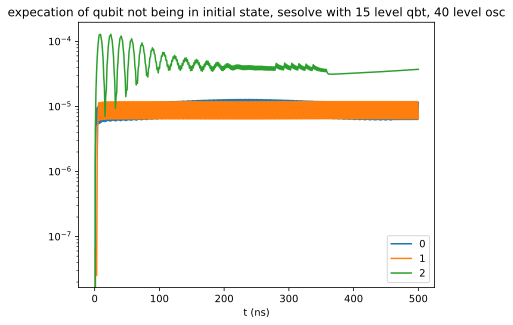

In [9]:
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

t loop: 100%|██████████| 500/500 [01:26<00:00,  5.78it/s]


Text(0.5, 0, 't (ns)')

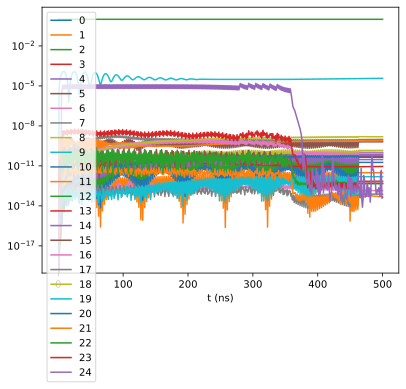

In [10]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)


for ql,pop_list in enumerate(lists[2][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [11]:
with open('../pickles/sesolve_01_large_dim_qubit_pop_list.pkl', 'wb') as file:
    pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

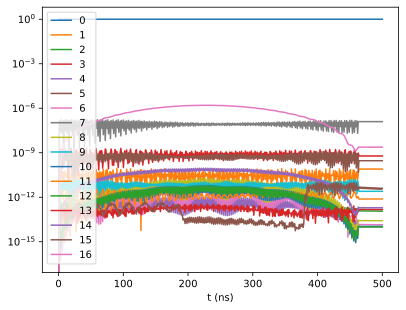

In [8]:

for ql,pop_list in enumerate(lists[0][:17]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

Text(0.5, 0, 't (ns)')

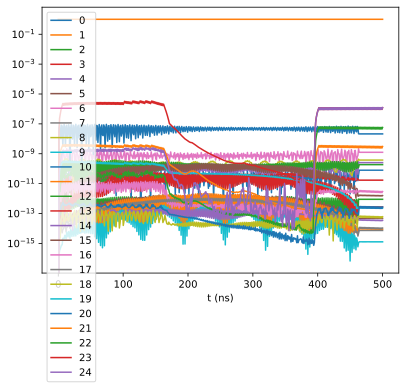

In [9]:

for ql,pop_list in enumerate(lists[1][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [8]:
from matplotlib.colors import LogNorm
def plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'states'):
        dm = result.states[time_index]
    elif hasattr(result, 'y'):
        dm = result.y[time_index]

    # dm = pad_back_function(dm)
    grid = np.zeros(( qubit_levels,oscillator_levels))

    for qubit_level in range(qubit_levels):
        for oscillator_level in range(oscillator_levels):
            product_state = (qubit_level, oscillator_level)
            dressed_state = product_to_dressed[product_state]
            if dressed_state < dm.dims[0][0]:
                # Create a basis state corresponding to the dressed state
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                # Calculate the expectation value
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
            else:
                expectation_value = 0
            grid[ qubit_level,oscillator_level] = expectation_value
    grid[grid < 1e-11] = 1e-11
    plt.imshow(grid, cmap='viridis', origin='lower',norm=LogNorm())
    plt.colorbar(label='Expectation Value')
    plt.xlabel('Oscillator Level')
    plt.ylabel('Qubit Level')
    
    plt.title(f'Expectation Values at t = {result.times[time_index]}')
    plt.show()

def interactive_heatmap(result, product_to_dressed, qubit_levels, oscillator_levels):
    if hasattr(result, 'times'):
        times = result.times
    elif hasattr(result, 't'):
        times = result.t
    time_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(times) - 1,
        step=1,
        description='Time Index:',
        continuous_update=False
    )
    
    widgets.interact(lambda time_index: plot_heatmap(result, time_index, product_to_dressed, qubit_levels, oscillator_levels),
                     time_index=time_slider)
    

In [12]:
interactive_heatmap(results[2], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=329), Output(…

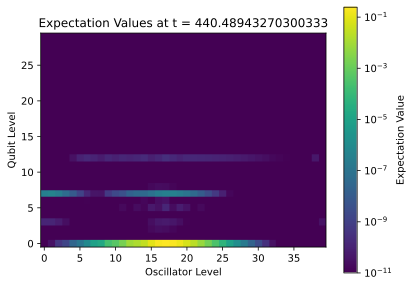

In [26]:
plot_heatmap(results[0], time_index=440, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

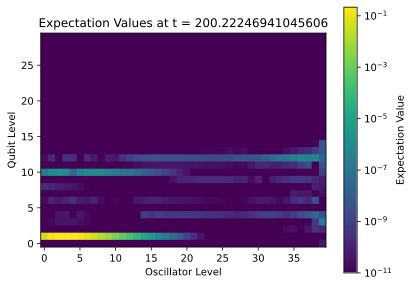

In [27]:
plot_heatmap(results[1], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

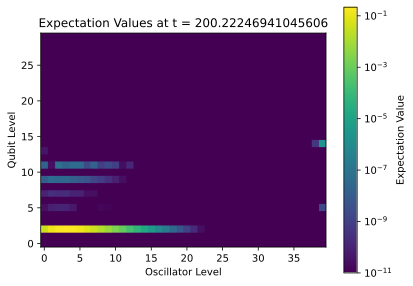

In [28]:
plot_heatmap(results[2], time_index=200, product_to_dressed = product_to_dressed, qubit_levels=qubit_level, oscillator_levels=osc_level)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

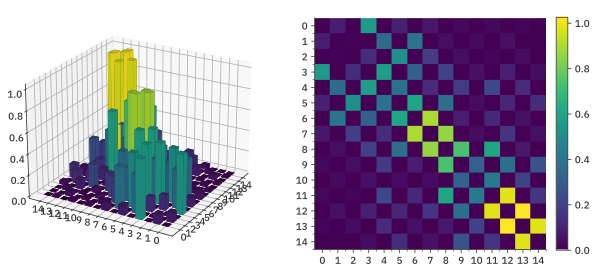

In [29]:
qbt.plot_matrixelements('n_operator',evals_count=15)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

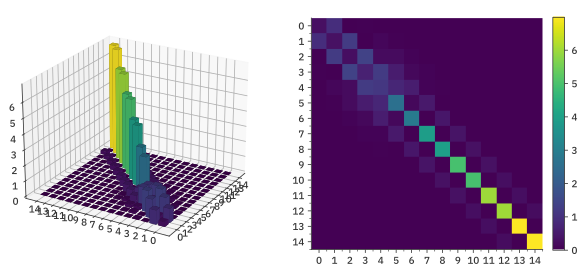

In [30]:
scqubits.Transmon(EJ=30,EC=1.2,ng=0.3,ncut=31).plot_matrixelements('n_operator',evals_count=15)